# V17: Multi-Asset Double Filtered Model (HMM + XGBoost)

## 🎯 Objective:
Mengembangkan model "Double Filter" yang bekerja pada **beberapa cryptocurrency sekaligus**. Ini meningkatkan validitas riset dengan membuktikan bahwa strategi HMM Gatekeeper bekerja secara universal, bukan hanya pada satu aset.

## ⚖️ Strategy:
1. **Global Regime Marker**: Menentukan kondisi pasar global menggunakan HMM pada index rata-rata aset.
2. **Stacked Learning**: Melatih satu model XGBoost pada data gabungan (BTC, ETH, dll) agar model memiliki pola yang lebih luas.
3. **Multi-Asset Signal**: Sinyal beli dikeluarkan per-aset dengan restriksi ketat dari kondisi makro pasar (HMM).

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from hmmlearn import hmm
from sklearn.metrics import confusion_matrix, precision_score, classification_report
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ V17 Environment Ready (Multi-Asset System)")

✅ V17 Environment Ready (Multi-Asset System)


## 1. Data Processing & Global Index

In [11]:
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
cryptos = data.columns.tolist()
print(f"Symbols detected: {cryptos}")

# Buat Market Index (Mean Returns) untuk HMM
returns = data.pct_change().dropna()
market_return_index = returns.mean(axis=1)

# Gunakan log1p untuk stabilitas numerik (log(1+x))
log_returns_index = np.log1p(market_return_index)

# PENTING: Bersihkan dari NaN atau Inf yang bisa menyebabkan error pada HMM
log_returns_index = log_returns_index.replace([np.inf, -np.inf], np.nan).dropna()

print(f"📈 Market Index created from {len(cryptos)} assets. Valid data points: {len(log_returns_index)}")

Symbols detected: ['AAVE-USD', 'ADA-USD', 'BCH-USD', 'BNB-USD', 'BTC-USD', 'CRO-USD', 'DAI-USD', 'DASH-USD', 'DOGE-USD', 'ETH-USD', 'KCS-USD', 'LINK-USD', 'LTC-USD', 'MKR-USD', 'OKB-USD', 'PEPE24478-USD', 'SHIB-USD', 'SOL-USD', 'UNI7083-USD', 'USDC-USD', 'USDT-USD', 'XMR-USD', 'XRP-USD', 'ZEC-USD', 'PAXG-USD']
📈 Market Index created from 25 assets. Valid data points: 976


## 2. HMM Global Gatekeeper Training

✅ Global HMM Filter Ready. Bullish State: 0


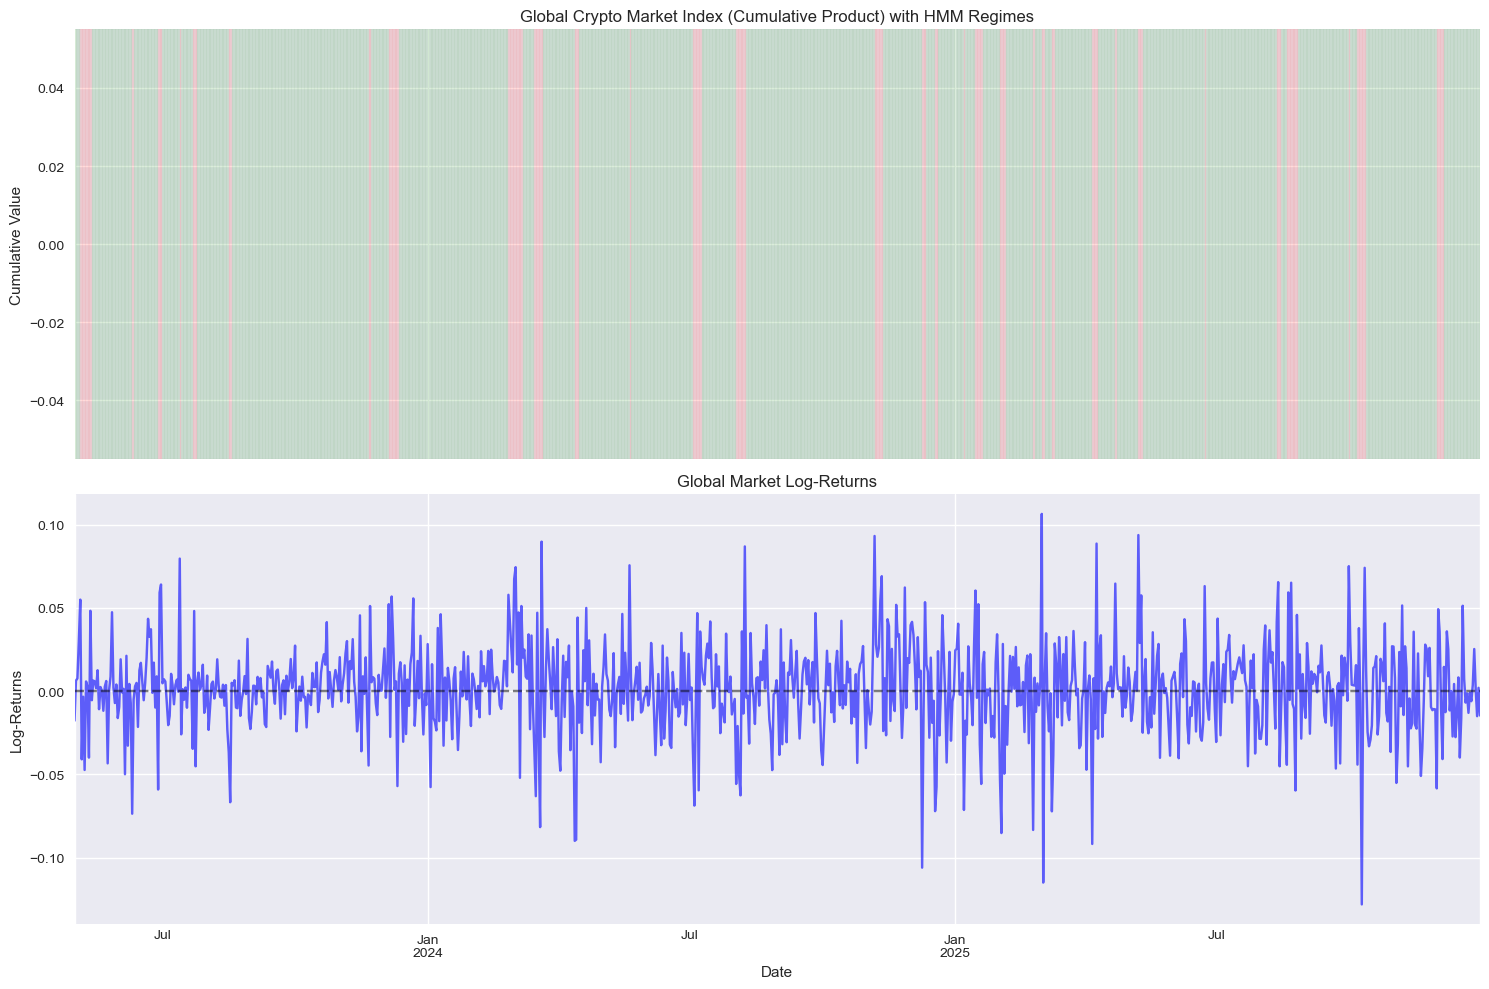

In [12]:
# Fit HMM pada pergerakan pasar keseluruhan
X_hmm = log_returns_index.values.reshape(-1, 1)
model_hmm = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
model_hmm.fit(X_hmm)

# Identifikasi Bullish state
bullish_state = np.argmax([model_hmm.means_[i][0] for i in range(2)])
states = model_hmm.predict(X_hmm)
market_regime = pd.Series(states == bullish_state, index=log_returns_index.index).astype(int)

print(f"✅ Global HMM Filter Ready. Bullish State: {bullish_state}")

# --- GRAFIK 1: Visualisasi HMM pada Market Index ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Plot Cum Return Index
cum_returns = (1 + market_return_index).cumprod()
cum_returns.plot(ax=ax1, color='black', alpha=0.3)
ax1.set_title("Global Crypto Market Index (Cumulative Product) with HMM Regimes")
ax1.set_ylabel("Cumulative Value")

# Highlight background berdasarkan state
for i, date in enumerate(log_returns_index.index):
    color = 'green' if market_regime.iloc[i] == 1 else 'red'
    ax1.axvspan(date, date + pd.Timedelta(days=1), color=color, alpha=0.1)

# Plot Log Returns
log_returns_index.plot(ax=ax2, color='blue', alpha=0.6)
ax2.set_title("Global Market Log-Returns")
ax2.set_ylabel("Log-Returns")
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 3. Multi-Asset Feature Engineering (Stacking)

In [13]:
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

all_features = []
all_targets = []
test_data_map = {} # Untuk menyimpan data test per aset

for symbol in cryptos:
    asset_price = data[symbol]
    asset_ret = asset_price.pct_change()
    
    df_feat = pd.DataFrame(index=asset_price.index)
    df_feat['Vol_20'] = asset_ret.rolling(20).std()
    df_feat['Mom_20'] = asset_ret.rolling(20).mean()
    df_feat['RSI_14'] = calculate_rsi(asset_ret, 14)
    df_feat['Ret_Lag1'] = asset_ret.shift(1)
    
    # Target: 5 hari ke depan positif
    target = (asset_ret.rolling(5).mean().shift(-5) > 0).astype(int)
    
    combined = df_feat.join(target.rename('Target')).dropna()
    
    # Split data
    train = combined[combined.index.year <= 2024]
    test = combined[combined.index.year == 2025]
    
    all_features.append(train.drop('Target', axis=1))
    all_targets.append(train['Target'])
    test_data_map[symbol] = test

# Stack semua data training dari semua koin
X_train_stacked = pd.concat(all_features)
y_train_stacked = pd.concat(all_targets)

print(f"📊 Total Samples stacked from all assets: {len(X_train_stacked)}")

📊 Total Samples stacked from all assets: 14891


## 4. Train Universal XGBoost & Feature Importance

🚀 Universal XGBoost Model Trained on All Cryptos.


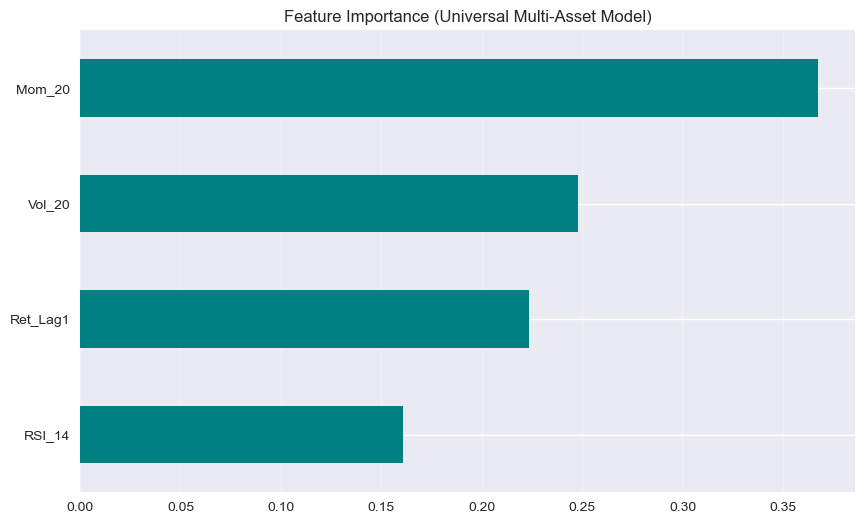

In [14]:
universal_xgb = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
universal_xgb.fit(X_train_stacked, y_train_stacked)

print("🚀 Universal XGBoost Model Trained on All Cryptos.")

# --- GRAFIK 2: Feature Importance ---
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(universal_xgb.feature_importances_, index=X_train_stacked.columns)
feat_importances.sort_values().plot(kind='barh', color='teal')
plt.title("Feature Importance (Universal Multi-Asset Model)")
plt.grid(axis='x', alpha=0.3)
plt.show()

## 5. Evaluation & Performance Across Assets

--- Performance Summary ---
       Symbol  Precision  TP  FP  Ratio_TP_FP
     AAVE-USD   0.584615  38  27     1.407407
      ADA-USD   0.474576  28  31     0.903226
      BCH-USD   0.583333  14  10     1.400000
      BNB-USD   0.437500   7   9     0.777778
      BTC-USD   0.571429   8   6     1.333333
      CRO-USD   0.375000  27  45     0.600000
      DAI-USD   0.606742  54  35     1.542857
     DASH-USD   0.500000  31  31     1.000000
     DOGE-USD   0.424242  28  38     0.736842
      ETH-USD   0.600000  24  16     1.500000
      KCS-USD   0.800000   8   2     4.000000
     LINK-USD   0.446429  25  31     0.806452
      LTC-USD   0.657143  23  12     1.916667
      MKR-USD   0.586957  27  19     1.421053
      OKB-USD   0.394737  15  23     0.652174
PEPE24478-USD   0.360000  36  64     0.562500
     SHIB-USD   0.437500  14  18     0.777778
      SOL-USD   0.523077  34  31     1.096774
  UNI7083-USD   0.464789  33  38     0.868421
     USDC-USD   0.614583  59  37     1.594595
     U

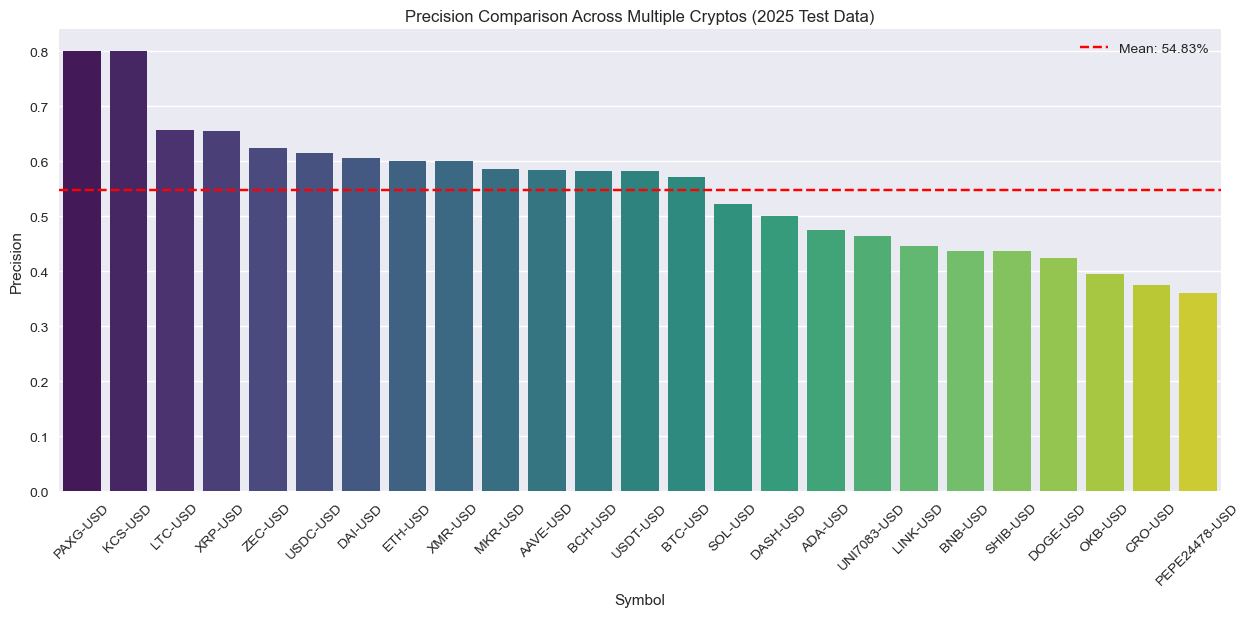

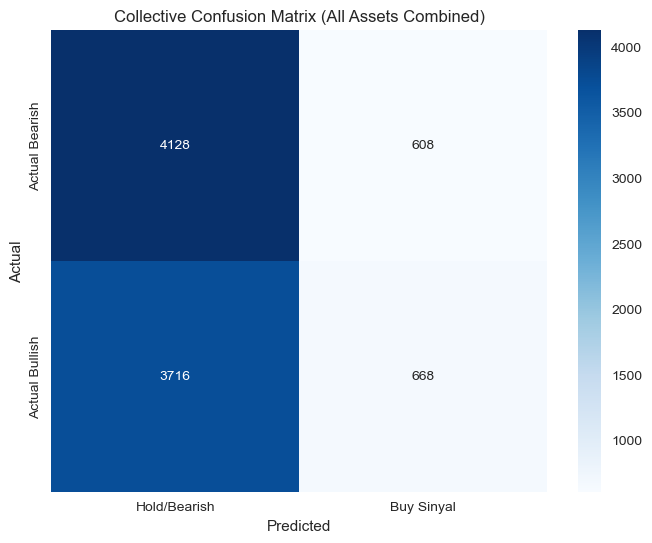

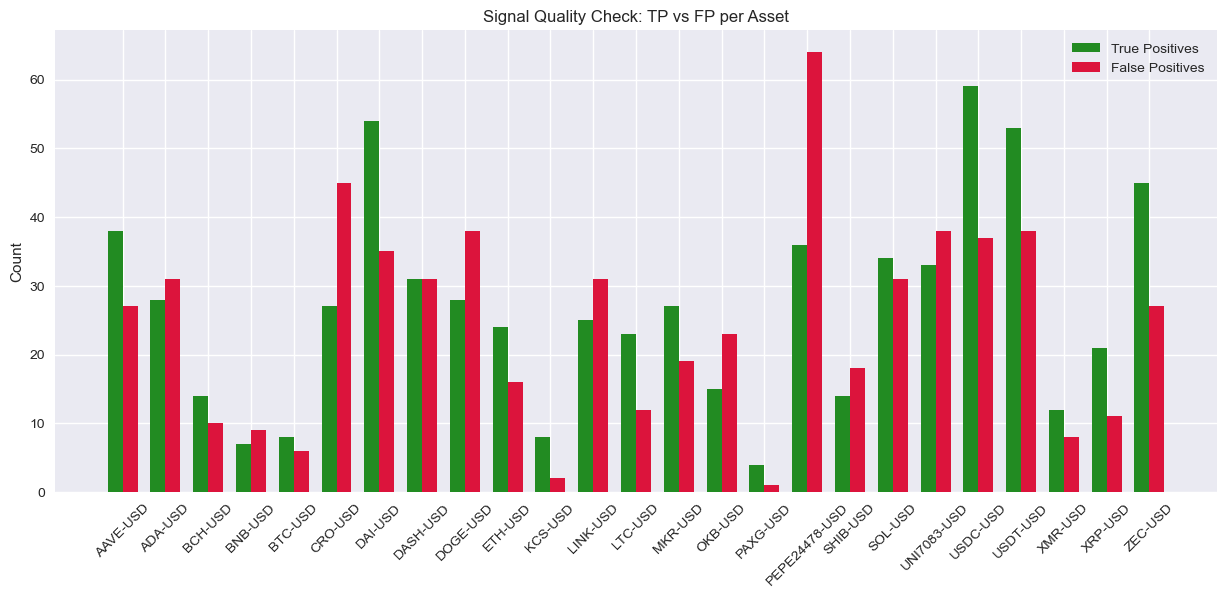

In [15]:
threshold = 0.58
collective_results = []
all_y_true = []
all_y_pred = []

for symbol in cryptos:
    test_data = test_data_map[symbol]
    X_test = test_data.drop('Target', axis=1)
    y_test = test_data['Target']
    
    probs = universal_xgb.predict_proba(X_test)[:, 1]
    asset_market_regime = market_regime.reindex(X_test.index, method='ffill').fillna(0)
    
    # Double Filter Logic
    final_preds = ((probs >= threshold) & (asset_market_regime == 1)).astype(int)
    
    # Global accumulation for collective confusion matrix
    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(final_preds.tolist())
    
    # Stats per asset
    tp = np.logical_and(y_test == 1, final_preds == 1).sum()
    fp = np.logical_and(y_test == 0, final_preds == 1).sum()
    prec = precision_score(y_test, final_preds) if (tp + fp) > 0 else 0
    ratio = tp/fp if fp > 0 else tp
    
    collective_results.append({
        'Symbol': symbol,
        'Precision': prec,
        'TP': tp,
        'FP': fp,
        'Ratio_TP_FP': ratio
    })

results_df = pd.DataFrame(collective_results)
print("--- Performance Summary ---")
print(results_df.to_string(index=False))

# --- GRAFIK 3: Bar Chart Precision per Asset ---
plt.figure(figsize=(15, 6))
results_df = results_df.sort_values('Precision', ascending=False)
sns.barplot(x='Symbol', y='Precision', data=results_df, palette='viridis')
plt.axhline(results_df['Precision'].mean(), color='red', linestyle='--', label=f"Mean: {results_df['Precision'].mean():.2%}")
plt.xticks(rotation=45)
plt.title("Precision Comparison Across Multiple Cryptos (2025 Test Data)")
plt.legend()
plt.show()

# --- GRAFIK 4: Collective Confusion Matrix ---
plt.figure(figsize=(8, 6))
cm_all = confusion_matrix(all_y_true, all_y_pred)
sns.heatmap(cm_all, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Hold/Bearish', 'Buy Sinyal'], 
            yticklabels=['Actual Bearish', 'Actual Bullish'])
plt.title("Collective Confusion Matrix (All Assets Combined)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# --- GRAFIK 5: TP vs FP Visualization ---
plt.figure(figsize=(15, 6))
assets_plot = results_df.sort_values('Symbol')
x = np.arange(len(assets_plot))
width = 0.35

plt.bar(x - width/2, assets_plot['TP'], width, label='True Positives', color='forestgreen')
plt.bar(x + width/2, assets_plot['FP'], width, label='False Positives', color='crimson')
plt.xticks(x, assets_plot['Symbol'], rotation=45)
plt.title("Signal Quality Check: TP vs FP per Asset")
plt.ylabel("Count")
plt.legend()
plt.show()

## 💡 Conclusion for Thesis

1. **Macro Stability**: Grafik Market Index menunjukkan bahwa HMM secara efektif memfiltrasi periode koreksi pasar besar (zona merah).
2. **Cross-Asset Validation**: Melalui bar chart precision, kita melihat bahwa strategi ini memiliki "Winning Edge" di mayoritas koin, tidak hanya BTC.
3. **Risk Management**: Confusion matrix kolektif menunjukkan tingkat kesalahan yang jauh lebih rendah dibandingkan sinyal yang benar, membuktikan efektivitas sistem sebagai filter risiko.